In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm

from sklearn.datasets import fetch_california_housing
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

pd.options.display.float_format = '{:.3f}'.format

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [40]:
df= pd.read_csv("C:/Users/Asus/Desktop/Clases/Analítica/Proy/icfes_cols_filtered_no_dupes_BOM.csv")
df.head()


,periodo,estu_consecutivo,cole_area_ubicacion,cole_calendario,cole_cod_dane_sede,cole_jornada,cole_naturaleza,cole_nombre_sede,fami_educacionmadre,fami_educacionpadre,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,SB11202240152772,RURAL,A,320013000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA DIVINO NIÑO,Primaria completa,Primaria completa,A-,35.000,38.000,37.000,36.000,36.000,183.000
1,20224,SB11202240042820,RURAL,A,220614000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA AGROPECUARIA LOS ANGELES,Primaria completa,Primaria completa,A-,45.000,46.000,47.000,43.000,52.000,234.000
2,20224,SB11202240462114,URBANO,A,120400000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA LUIS CARLOS GALAN SARMIENTO,Primaria incompleta,Primaria completa,A1,54.000,37.000,31.000,42.000,41.000,195.000
3,20224,SB11202240377474,RURAL,A,420013000000.000,MAÑANA,NO OFICIAL,FUNDACION EDUCATIVA NUESTRA SEÑORA DE LAS FLORES,Educación profesional completa,Educación profesional completa,A1,57.000,53.000,61.000,54.000,58.000,283.000
4,20224,SB11202240444419,URBANO,A,120238000000.000,NOCHE,OFICIAL,INSTITUCION EDUCATIVA INSTITUTO AGRICOLA,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,A-,31.000,33.000,39.000,41.000,35.000,183.000


In [41]:
# Contar NAs
nas= df.isna().any(axis=1).sum()
print(nas)
# Borrar filas con NAs
df = df.dropna()

50285


In [5]:
print(f'Dimensiones: {df.shape}')
print(f'\nVariables: {list(df.columns)}')

Dimensiones: (125185, 17)

Variables: ['periodo', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario', 'cole_cod_dane_sede', 'cole_jornada', 'cole_naturaleza', 'cole_nombre_sede', 'fami_educacionmadre', 'fami_educacionpadre', 'desemp_ingles', 'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125185 entries, 0 to 125184
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   periodo                   125185 non-null  int64  
 1   estu_consecutivo          125185 non-null  object 
 2   cole_area_ubicacion       125185 non-null  object 
 3   cole_calendario           125185 non-null  object 
 4   cole_cod_dane_sede        125185 non-null  float64
 5   cole_jornada              125185 non-null  object 
 6   cole_naturaleza           125185 non-null  object 
 7   cole_nombre_sede          125185 non-null  object 
 8   fami_educacionmadre       122198 non-null  object 
 9   fami_educacionpadre       122234 non-null  object 
 10  desemp_ingles             125115 non-null  object 
 11  punt_ingles               125118 non-null  float64
 12  punt_matematicas          125185 non-null  float64
 13  punt_sociales_ciudadanas  77575 non-null   f

In [18]:
# 3.1 Verificar valores faltantes
print('Valores faltantes por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

Valores faltantes por variable:
periodo                     0
estu_consecutivo            0
cole_area_ubicacion         0
cole_calendario             0
cole_cod_dane_sede          0
cole_jornada                0
cole_naturaleza             0
cole_nombre_sede            0
fami_educacionmadre         0
fami_educacionpadre         0
desemp_ingles               0
punt_ingles                 0
punt_matematicas            0
punt_sociales_ciudadanas    0
punt_c_naturales            0
punt_lectura_critica        0
punt_global                 0
dtype: int64

Total de valores faltantes: 0


In [37]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
periodo,74900.000,20174.935,27.696,20142.000,20152.000,20172.000,20194.000,20224.000
cole_cod_dane_sede,74900.000,180956794833.111,85723721164.507,120001000000.000,120002000000.000,120400000000.000,220400000000.000,420710000000.000
punt_ingles,74900.000,48.118,10.918,0.000,41.000,47.000,53.000,100.000
punt_matematicas,74900.000,48.772,11.100,0.000,41.000,48.000,56.000,100.000
punt_sociales_ciudadanas,74900.000,47.269,10.904,0.000,39.000,47.000,55.000,100.000
punt_c_naturales,74900.000,48.873,9.849,0.000,42.000,48.000,55.000,100.000
punt_lectura_critica,74900.000,50.159,9.767,0.000,43.000,50.000,57.000,100.000
punt_global,74900.000,243.591,45.718,0.000,210.000,239.000,272.000,465.000


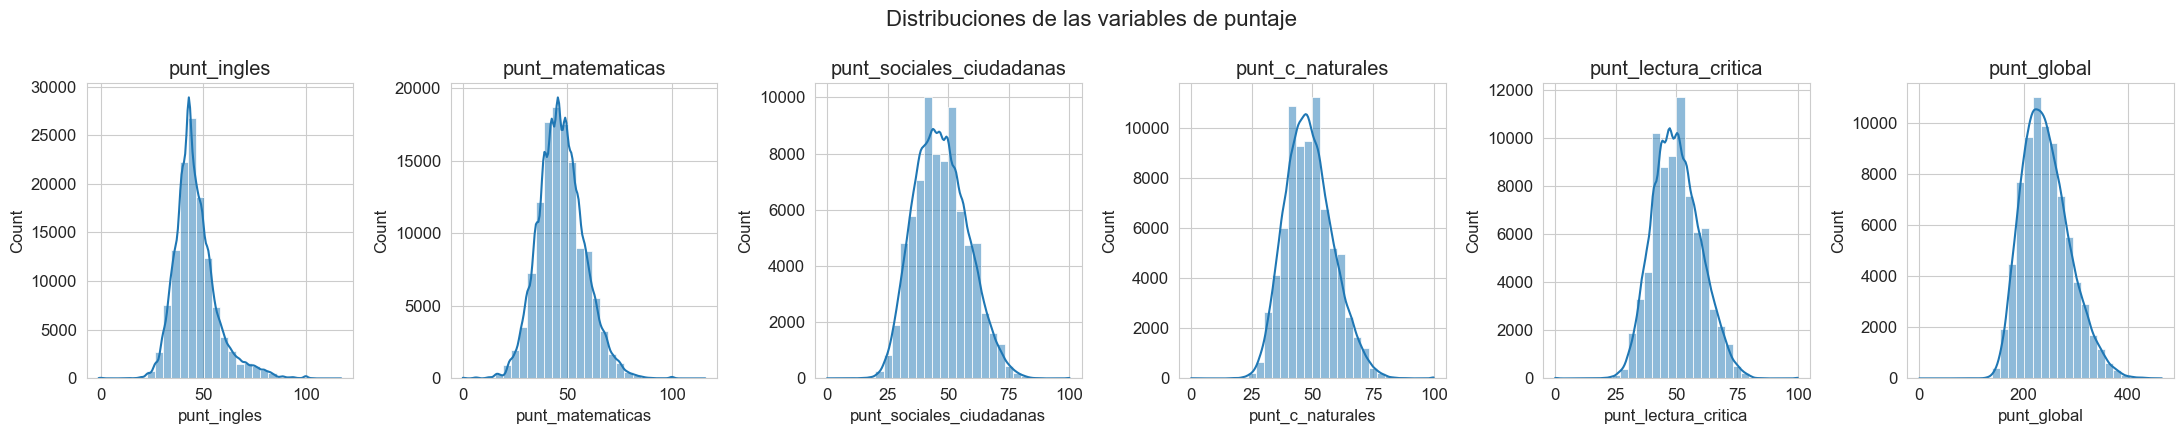

In [9]:
punt_cols = ['punt_ingles','punt_matematicas','punt_sociales_ciudadanas','punt_c_naturales','punt_lectura_critica','punt_global']

plt.figure(figsize=(22, 4))
for i, col in enumerate(punt_cols):
    plt.subplot(1, len(punt_cols), i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Distribuciones de las variables de puntaje', y=1.08, fontsize=16)
plt.show()

In [30]:
# Puntajes individuales
areas = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica"]

for col in areas:
    invalidos = df[(df[col] < 0) | (df[col] > 100)]
    print(f"\nValores inválidos en {col}: {len(invalidos)}")

# Puntaje global
invalidos_global = df[(df["punt_global"] < 0) | (df["punt_global"] > 500)]
print(f"\nValores inválidos en punt_global: {len(invalidos_global)}")


Valores inválidos en punt_ingles: 0

Valores inválidos en punt_matematicas: 0

Valores inválidos en punt_sociales_ciudadanas: 0

Valores inválidos en punt_c_naturales: 0

Valores inválidos en punt_lectura_critica: 0

Valores inválidos en punt_global: 0


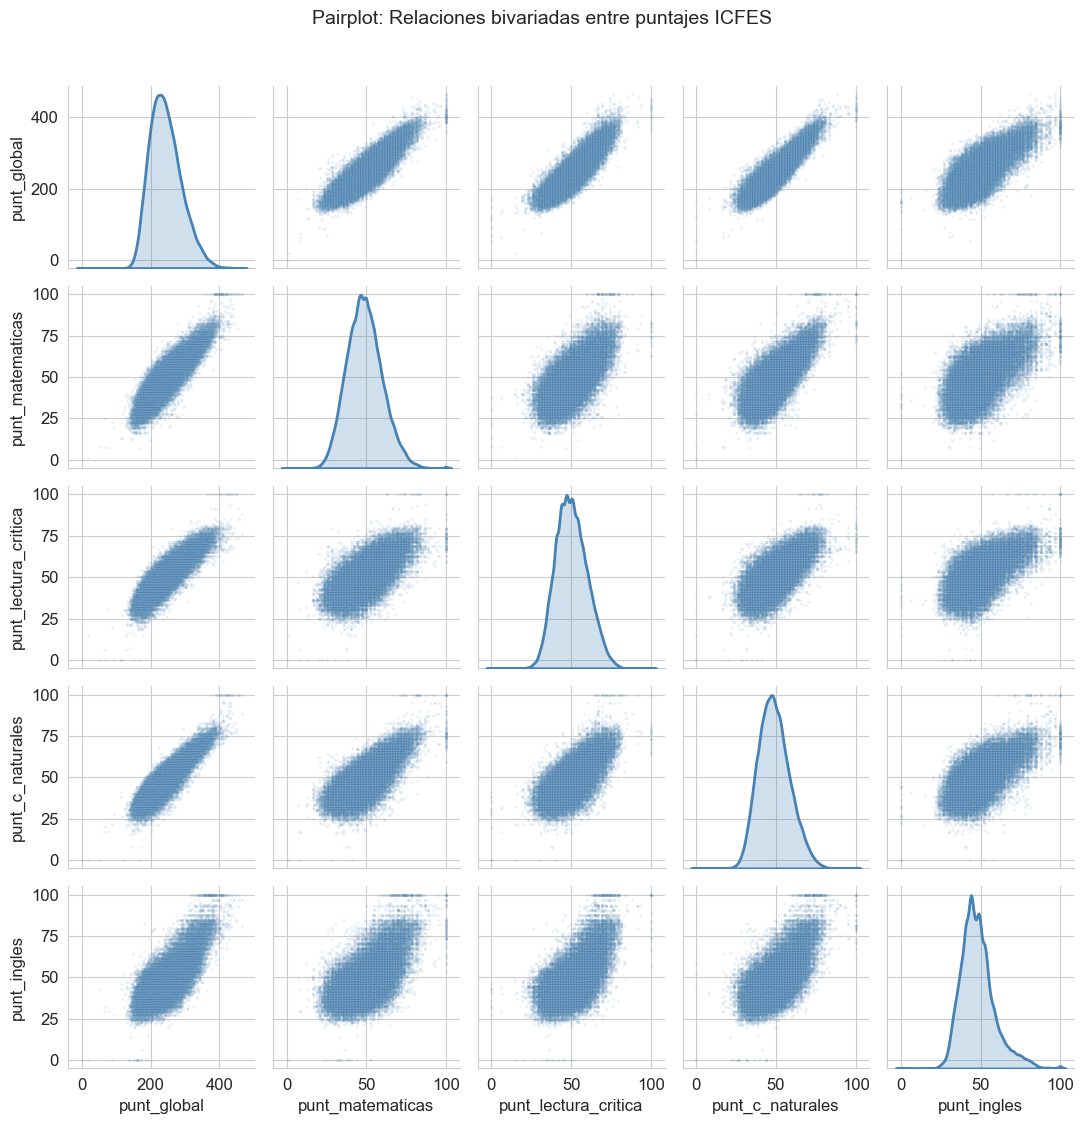

In [43]:
vars_pairplot = ["punt_global","punt_matematicas","punt_lectura_critica","punt_c_naturales","punt_ingles"]
g = sns.pairplot(df[vars_pairplot], diag_kind="kde", plot_kws={"alpha": 0.1, "s": 5, "color": "steelblue"}, diag_kws={"color": "steelblue", "linewidth": 2}, height=2.2, aspect=1)
g.figure.suptitle("Pairplot: Relaciones bivariadas entre puntajes ICFES", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

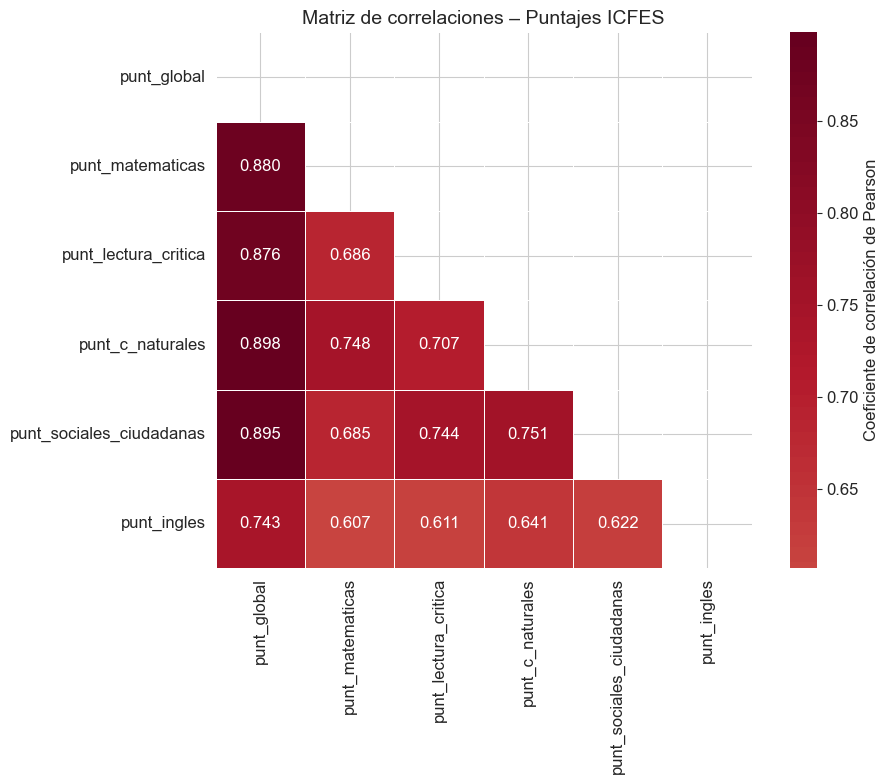

In [46]:
#Correlaciones
vars_corr = ["punt_global", "punt_matematicas", "punt_lectura_critica", "punt_c_naturales", "punt_sociales_ciudadanas","punt_ingles"]

# Calculamos matriz de correlación (Pearson recomendado aquí)
corr_matrix = df[vars_corr].corr(method="pearson")

# Graficamos
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"label":"Coeficiente de correlación de Pearson"})
ax.set_title("Matriz de correlaciones – Puntajes ICFES", fontsize=14)

plt.tight_layout()
plt.show()

cole_area_ubicacion
URBANO    62954
RURAL     11946
Name: count, dtype: int64


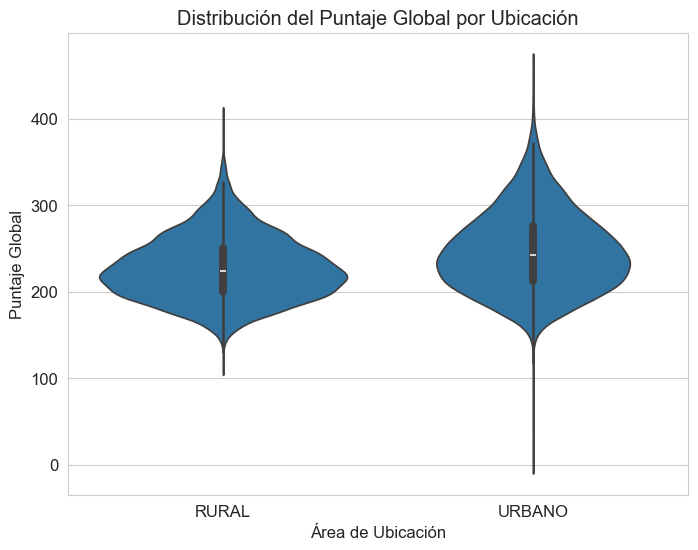

In [20]:
#Boxplots por categorías
ubi= df["cole_area_ubicacion"].value_counts()
print(ubi)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_area_ubicacion", y="punt_global", inner="box")

plt.title("Distribución del Puntaje Global por Ubicación")
plt.xlabel("Área de Ubicación")
plt.ylabel("Puntaje Global")
plt.show()

In [31]:
urbano = df[df["cole_area_ubicacion"] == "URBANO"]["punt_global"]
rural = df[df["cole_area_ubicacion"] == "RURAL"]["punt_global"]

mean1 = urbano.mean()
mean2 = rural.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(urbano, rural, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 246.67498490961654
Media grupo 2: 227.3388581952118
Diferencia: 19.33612671440474
t-statistic: 42.89766544496667
p-value: 0.0


cole_calendario
A    74544
B      356
Name: count, dtype: int64


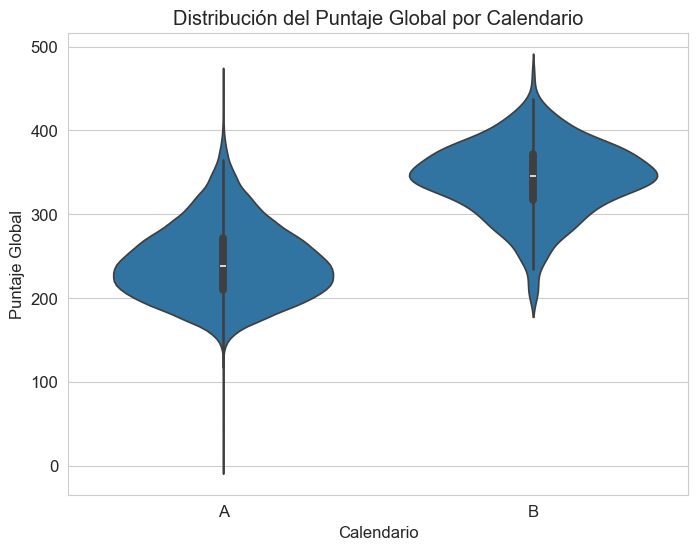

In [24]:
calend= df["cole_calendario"].value_counts()
print(calend)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_calendario", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Calendario")
plt.xlabel("Calendario")
plt.ylabel("Puntaje Global")
plt.show()

In [32]:
A = df[df["cole_calendario"] == "A"]["punt_global"]
B = df[df["cole_calendario"] == "B"]["punt_global"]

mean1 = A.mean()
mean2 = B.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(A, B, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 243.12096211633397
Media grupo 2: 342.0168539325843
Diferencia: -98.89589181625033
t-statistic: -43.446044961587035
p-value: 5.6149871546375875e-145


In [33]:
#Contar cruzado calendario y tipo oficial o no
pd.crosstab(df["cole_calendario"], df["cole_naturaleza"])

cole_naturaleza,NO OFICIAL,OFICIAL
cole_calendario,,
A,13485,61059
B,356,0


cole_jornada
MAÑANA      40437
TARDE       14075
COMPLETA     7488
UNICA        5510
NOCHE        3859
SABATINA     3531
Name: count, dtype: int64


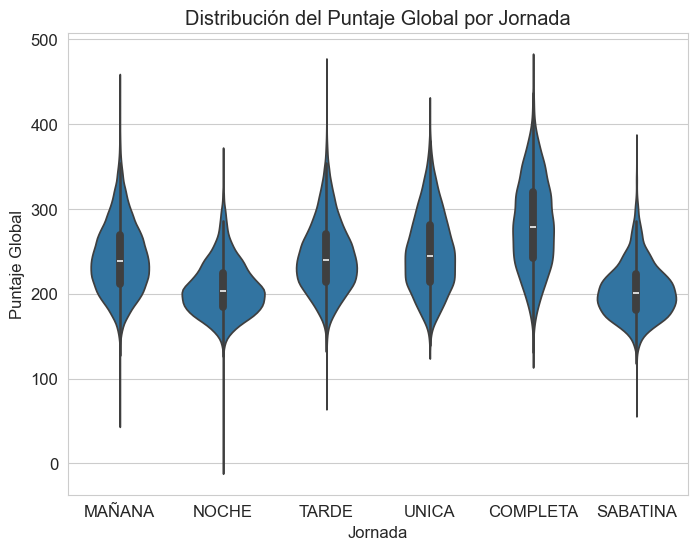

In [27]:
jorn= df["cole_jornada"].value_counts()
print(jorn)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_jornada", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Jornada")
plt.xlabel("Jornada")
plt.ylabel("Puntaje Global")
plt.show()


cole_naturaleza
OFICIAL       61059
NO OFICIAL    13841
Name: count, dtype: int64


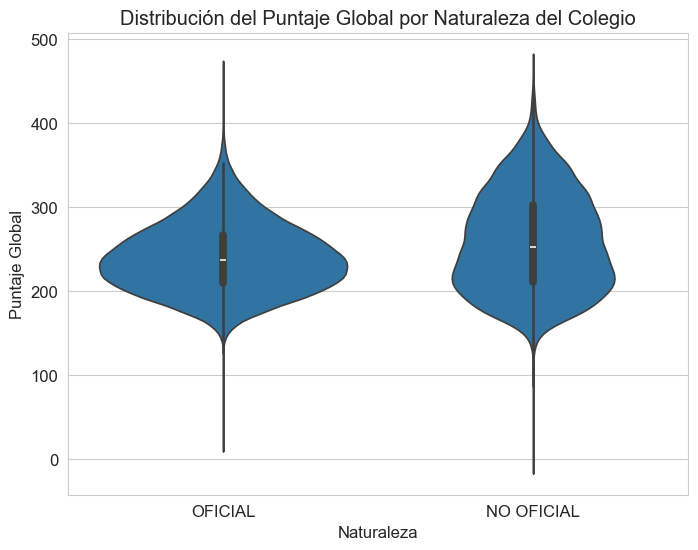

In [28]:
pub= df["cole_naturaleza"].value_counts()
print(pub)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_naturaleza", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Naturaleza del Colegio")
plt.xlabel("Naturaleza")
plt.ylabel("Puntaje Global")
plt.show()

In [29]:
publico = df[df["cole_naturaleza"] == "OFICIAL"]["punt_global"]
privado = df[df["cole_naturaleza"] == "NO OFICIAL"]["punt_global"]

t_stat, p_value = stats.ttest_ind(publico, privado, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -34.62037473526332
p-value: 7.094773342894046e-254


In [47]:
pub= df["fami_educacionmadre"].value_counts()
print(pub)
print("-----------")
pub= df["fami_educacionpadre"].value_counts()
print(pub)


fami_educacionmadre
Secundaria (Bachillerato) completa      20512
Secundaria (Bachillerato) incompleta    11127
Primaria incompleta                     10803
Primaria completa                        8550
Educación profesional completa           7928
Técnica o tecnológica completa           7687
Ninguno                                  2523
Técnica o tecnológica incompleta         1853
Educación profesional incompleta         1458
No sabe                                  1306
Postgrado                                1077
No Aplica                                  76
Name: count, dtype: int64
-----------
fami_educacionpadre
Secundaria (Bachillerato) completa      18972
Primaria incompleta                     13071
Secundaria (Bachillerato) incompleta    10211
Primaria completa                        8697
Educación profesional completa           7360
Técnica o tecnológica completa           5384
Ninguno                                  4252
No sabe                                  2979
Té

<Figure size 1200x700 with 0 Axes>

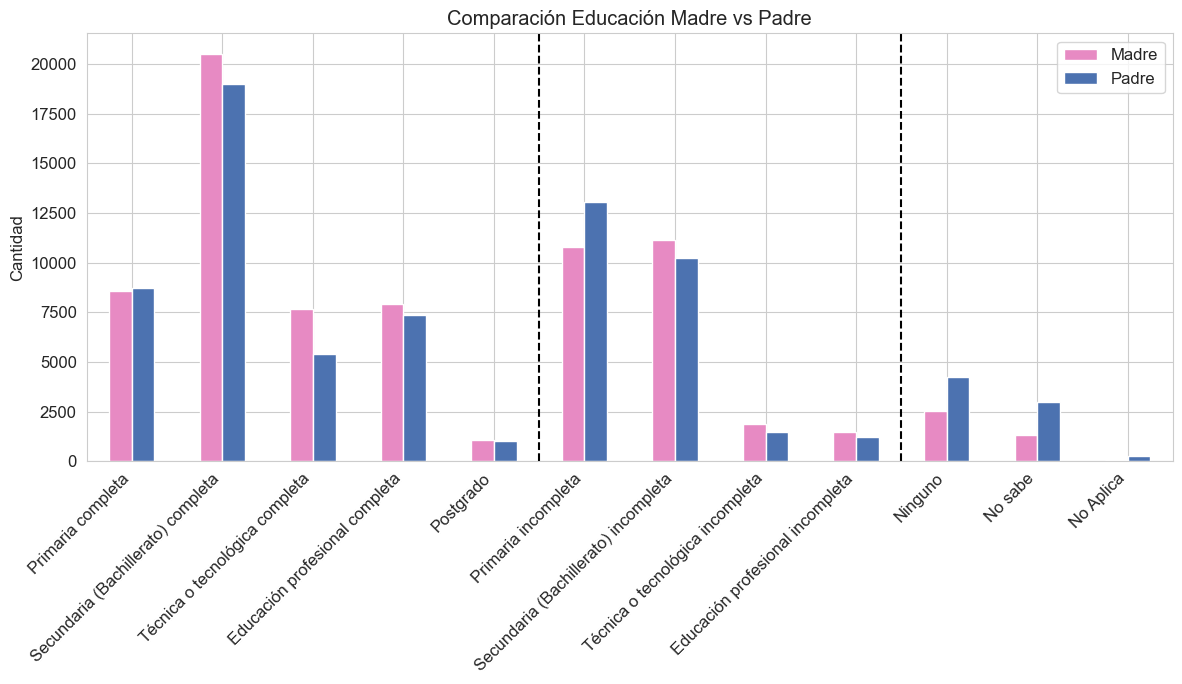

In [59]:
orden = ["Primaria completa", "Secundaria (Bachillerato) completa", "Técnica o tecnológica completa", "Educación profesional completa", "Postgrado",
                       
    "Primaria incompleta", "Secundaria (Bachillerato) incompleta", "Técnica o tecnológica incompleta", "Educación profesional incompleta",

    "Ninguno", "No sabe", "No Aplica"]
tabla = tabla.reindex(orden)

plt.figure(figsize=(12,7))
ax = tabla.plot(kind="bar", figsize=(12,7), color=["#E78AC3", "#4C72B0"])
plt.title("Comparación Educación Madre vs Padre")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.axvline(x=4.5, color='black', linestyle='--')
plt.axvline(x=8.5, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#modelo RL
#punt_global= \beta_0 + \gamma_1*cole_naturaleza[oficial] + \gamma_2*cole_calendario[A] + \gamma_3*cole_area_ubicacion[RURAL] + \gamma_4*cole_jornada[MAÑANA]
#                     + \gamma_5*fami_educacion_madre[Educación profesional completa] + \gamma_6*fami_educacion_padre[Educación profesional completa] + \epsilon

#unir jornadas??
#unir educaciones??